### Imports

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
import openchord as ocd

### Load kedro

In [2]:
import os

os.chdir("../../")

%load_ext kedro.ipython

[03/02/26 21:14:55] INFO     Using                                                                  ]8;id=281403;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=766334;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=445260;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=442932;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=219444;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=305161;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=116885;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=964476;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[03/02/26 21:14:57] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=428781;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=513711;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

                    WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=498764;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=778735;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[03/02/26 21:15:02] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=271953;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=266329;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[03/02/26 21:15:03] INFO     Kedro project cxr-training-pipeline                                    ]8;id=651797;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=175353;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=213035;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=491797;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=795244;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=955918;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

In [3]:
print(f"Current path: {os.getcwd()}")

Current path: c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeline


### Load CSV

In [4]:
metadata = catalog.load("cxr8_metadata")

                    INFO     Loading data from cxr8_metadata (CSVDataset)...                   ]8;id=877994;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=61588;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

# First look at the data

### 1. Basic information

In [5]:
rows, columns = metadata.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")
print(f"Dataset size : {metadata.size}")

Number of rows: 112120
Number of columns: 11
Dataset size : 1233320


### 2. Columns 

In [6]:
for column in metadata.columns:
    print(f"Column name: {column}")
    print(f"Number of unique values: {metadata[column].nunique()}")
    print(f"Missing values: {metadata[column].isnull().sum()}")
    print(f"Data types: {metadata[column].dtype}")
    print("-" * 40)

Column name: image_index
Number of unique values: 112120
Missing values: 0
Data types: object
----------------------------------------
Column name: finding_labels
Number of unique values: 836
Missing values: 0
Data types: object
----------------------------------------
Column name: follow-up #
Number of unique values: 184
Missing values: 0
Data types: int64
----------------------------------------
Column name: patient_id
Number of unique values: 30805
Missing values: 0
Data types: int64
----------------------------------------
Column name: patient_age
Number of unique values: 96
Missing values: 0
Data types: int64
----------------------------------------
Column name: patient_sex
Number of unique values: 2
Missing values: 0
Data types: object
----------------------------------------
Column name: view_position
Number of unique values: 2
Missing values: 0
Data types: object
----------------------------------------
Column name: original_image_width
Number of unique values: 904
Missing valu

# Labels Analysis

### 1. Unique Labels

In [7]:
unique_labels = metadata["finding_labels"].str.split("|").explode().unique()

for unique_label in unique_labels:
    count = metadata["finding_labels"].str.contains(unique_label).sum()
    print(f"Label: {unique_label}, Count: {count}")

Label: Cardiomegaly, Count: 2776
Label: Emphysema, Count: 2516
Label: Effusion, Count: 13317
Label: No Finding, Count: 60361
Label: Hernia, Count: 227
Label: Infiltration, Count: 19894
Label: Mass, Count: 5782
Label: Nodule, Count: 6331
Label: Atelectasis, Count: 11559
Label: Pneumothorax, Count: 5302
Label: Pleural_Thickening, Count: 3385
Label: Pneumonia, Count: 1431
Label: Fibrosis, Count: 1686
Label: Edema, Count: 2303
Label: Consolidation, Count: 4667


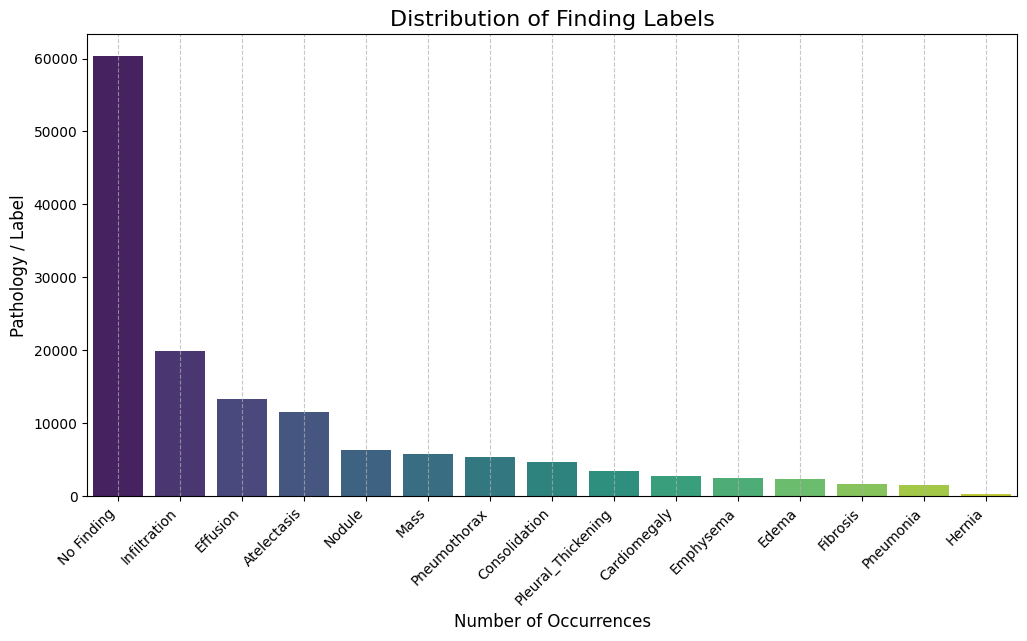

In [8]:
label_counts = metadata["finding_labels"].str.split("|").explode().value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

plt.title("Distribution of Finding Labels", fontsize=16)
plt.xlabel("Number of Occurrences", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Pathology / Label", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

In [9]:
for label in label_counts.index:
    count = label_counts[label]
    print(f"Label: {label} |  Count: {count} | Percentage: {count / len(metadata) * 100:.2f}%")

Label: No Finding |  Count: 60361 | Percentage: 53.84%
Label: Infiltration |  Count: 19894 | Percentage: 17.74%
Label: Effusion |  Count: 13317 | Percentage: 11.88%
Label: Atelectasis |  Count: 11559 | Percentage: 10.31%
Label: Nodule |  Count: 6331 | Percentage: 5.65%
Label: Mass |  Count: 5782 | Percentage: 5.16%
Label: Pneumothorax |  Count: 5302 | Percentage: 4.73%
Label: Consolidation |  Count: 4667 | Percentage: 4.16%
Label: Pleural_Thickening |  Count: 3385 | Percentage: 3.02%
Label: Cardiomegaly |  Count: 2776 | Percentage: 2.48%
Label: Emphysema |  Count: 2516 | Percentage: 2.24%
Label: Edema |  Count: 2303 | Percentage: 2.05%
Label: Fibrosis |  Count: 1686 | Percentage: 1.50%
Label: Pneumonia |  Count: 1431 | Percentage: 1.28%
Label: Hernia |  Count: 227 | Percentage: 0.20%


### 2. Multi-label analysis

In this part, we examine the frequency of multi-label instances within the dataset.

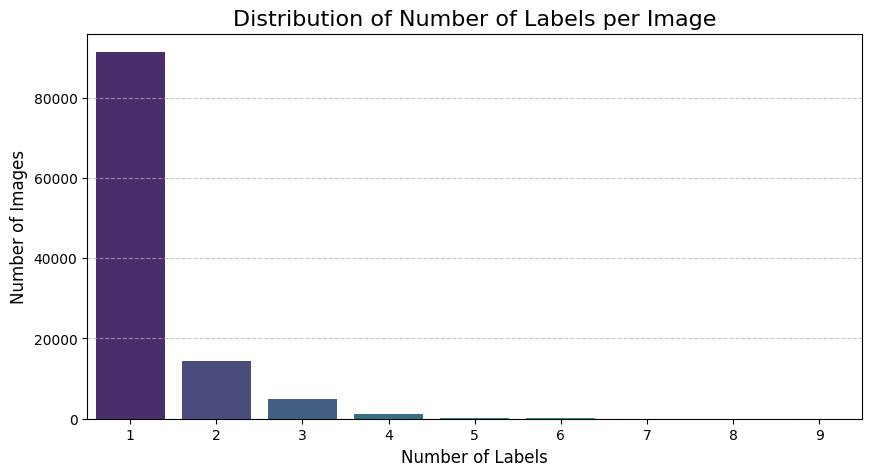

In [10]:
num_labels_per_row = metadata["finding_labels"].str.split("|").apply(len)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=num_labels_per_row.value_counts().sort_index().index,
    y=num_labels_per_row.value_counts().sort_index().values,
    palette="viridis",
)
plt.title("Distribution of Number of Labels per Image", fontsize=16)
plt.xlabel("Number of Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Below we will perform the same analysis, excluding the class 'No Finding', which is supposed to only appear as a single label.

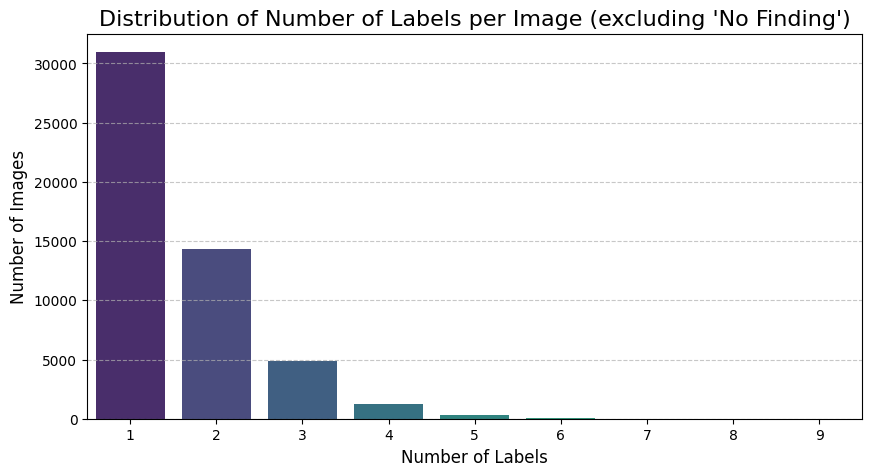

In [11]:
mask = metadata["finding_labels"].str.contains("No Finding")
num_labels_per_row_excluding_no_finding = metadata[~mask]["finding_labels"].str.split("|").apply(len)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=num_labels_per_row_excluding_no_finding.value_counts().sort_index().index,
    y=num_labels_per_row_excluding_no_finding.value_counts().sort_index().values,
    palette="viridis",
)
plt.title("Distribution of Number of Labels per Image (excluding 'No Finding')", fontsize=16)
plt.xlabel("Number of Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [12]:
counts = num_labels_per_row_excluding_no_finding.value_counts().sort_index()
total_len = len(metadata)
subset_len = len(num_labels_per_row_excluding_no_finding)

print(f"{'Labels':<10} | {'Count':<10} | {'Total %':<12} | {'Subset %':<12}")
print("-" * 55)

for entry, count in counts.items():
    total_pct = (count / total_len) * 100
    subset_pct = (count / subset_len) * 100

    count = num_labels_per_row_excluding_no_finding.value_counts().sort_index()[entry]
    print(
        f"Number of labels: {entry:<10} |  Count: {count:<10} | Percentage within total dataset: {count / len(metadata) * 100:.2f}% |  Percentage within non 'No Finding' subset: {count / len(num_labels_per_row_excluding_no_finding) * 100:.2f}%"
    )

Labels     | Count      | Total %      | Subset %    
-------------------------------------------------------
Number of labels: 1          |  Count: 30963      | Percentage within total dataset: 27.62% |  Percentage within non 'No Finding' subset: 59.82%
Number of labels: 2          |  Count: 14306      | Percentage within total dataset: 12.76% |  Percentage within non 'No Finding' subset: 27.64%
Number of labels: 3          |  Count: 4856       | Percentage within total dataset: 4.33% |  Percentage within non 'No Finding' subset: 9.38%
Number of labels: 4          |  Count: 1247       | Percentage within total dataset: 1.11% |  Percentage within non 'No Finding' subset: 2.41%
Number of labels: 5          |  Count: 301        | Percentage within total dataset: 0.27% |  Percentage within non 'No Finding' subset: 0.58%
Number of labels: 6          |  Count: 67         | Percentage within total dataset: 0.06% |  Percentage within non 'No Finding' subset: 0.13%
Number of labels: 7         

### 3. Connections between pathologies

In [50]:
pathologies = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax",
]


def create_cooccurrence_matrix(dataframe, pathologies):
    idx = {name: i for i, name in enumerate(pathologies)}
    n = len(pathologies)

    cooc = np.zeros((n, n), dtype=int)

    for _, row in dataframe.iterrows():
        labels = row["finding_labels"].split("|")
        indices = [idx[label] for label in labels if label in idx]

        for i, j in itertools.combinations_with_replacement(indices, 2):
            cooc[i, j] += 1
            if i != j:
                cooc[j, i] += 1

    return cooc


def create_ocd_chord(adjacency_matrix, labels):
    fig = ocd.Chord(adjacency_matrix, labels, radius=500)
    fig.padding = 350
    fig.font_size = 25
    return fig

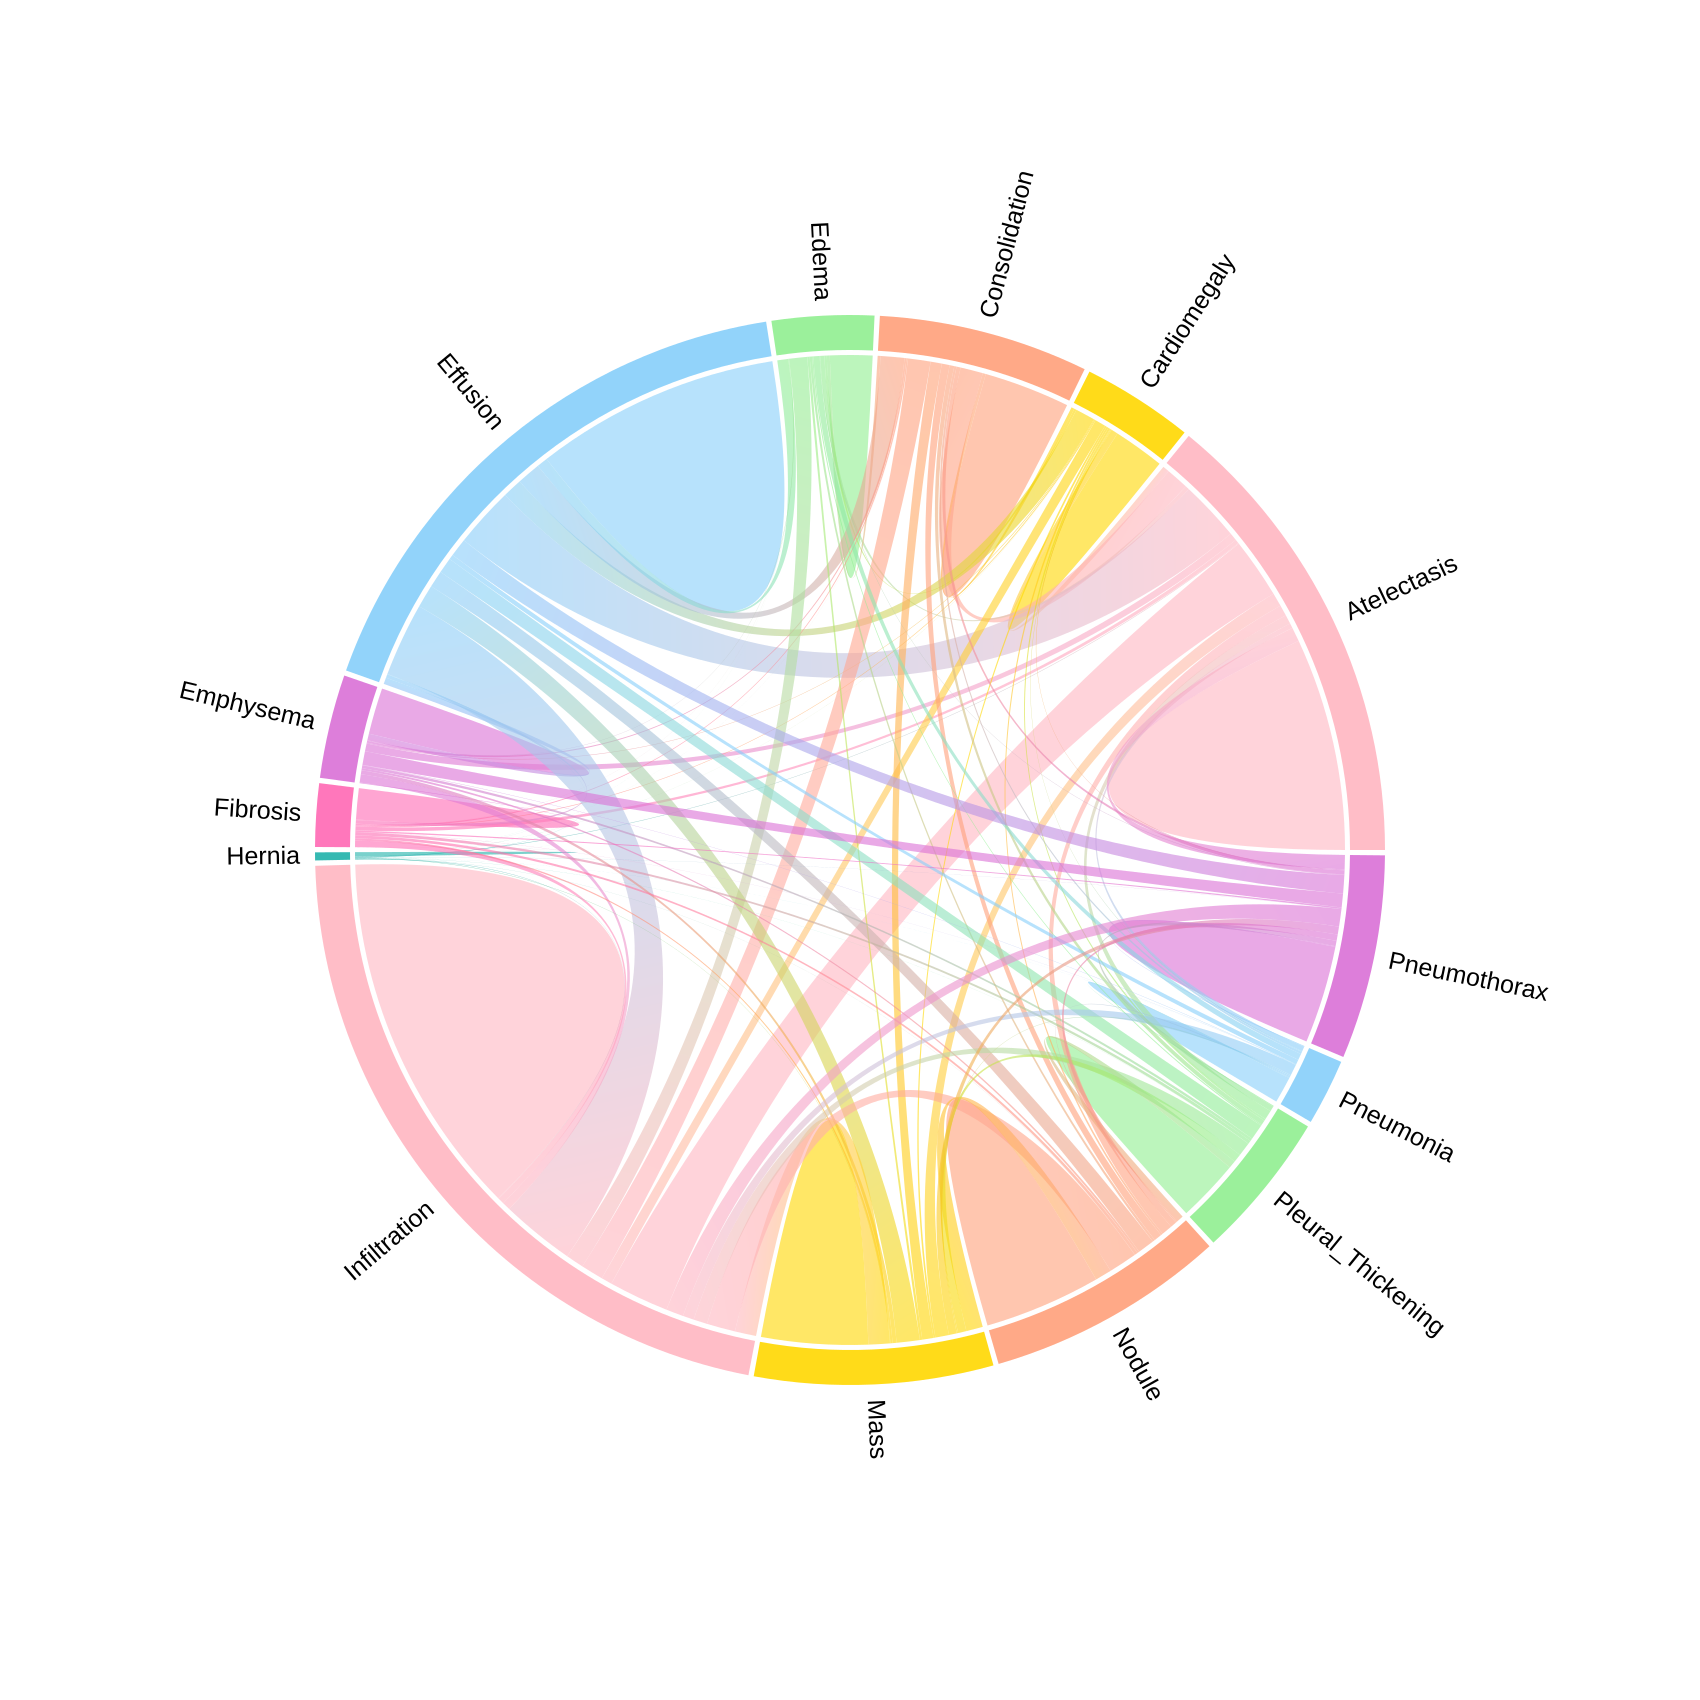

In [51]:
adjacency_matrix = create_cooccurrence_matrix(metadata, pathologies)
labels = pathologies
fig = create_ocd_chord(adjacency_matrix, labels)
fig.show()

The same plot but including the counts

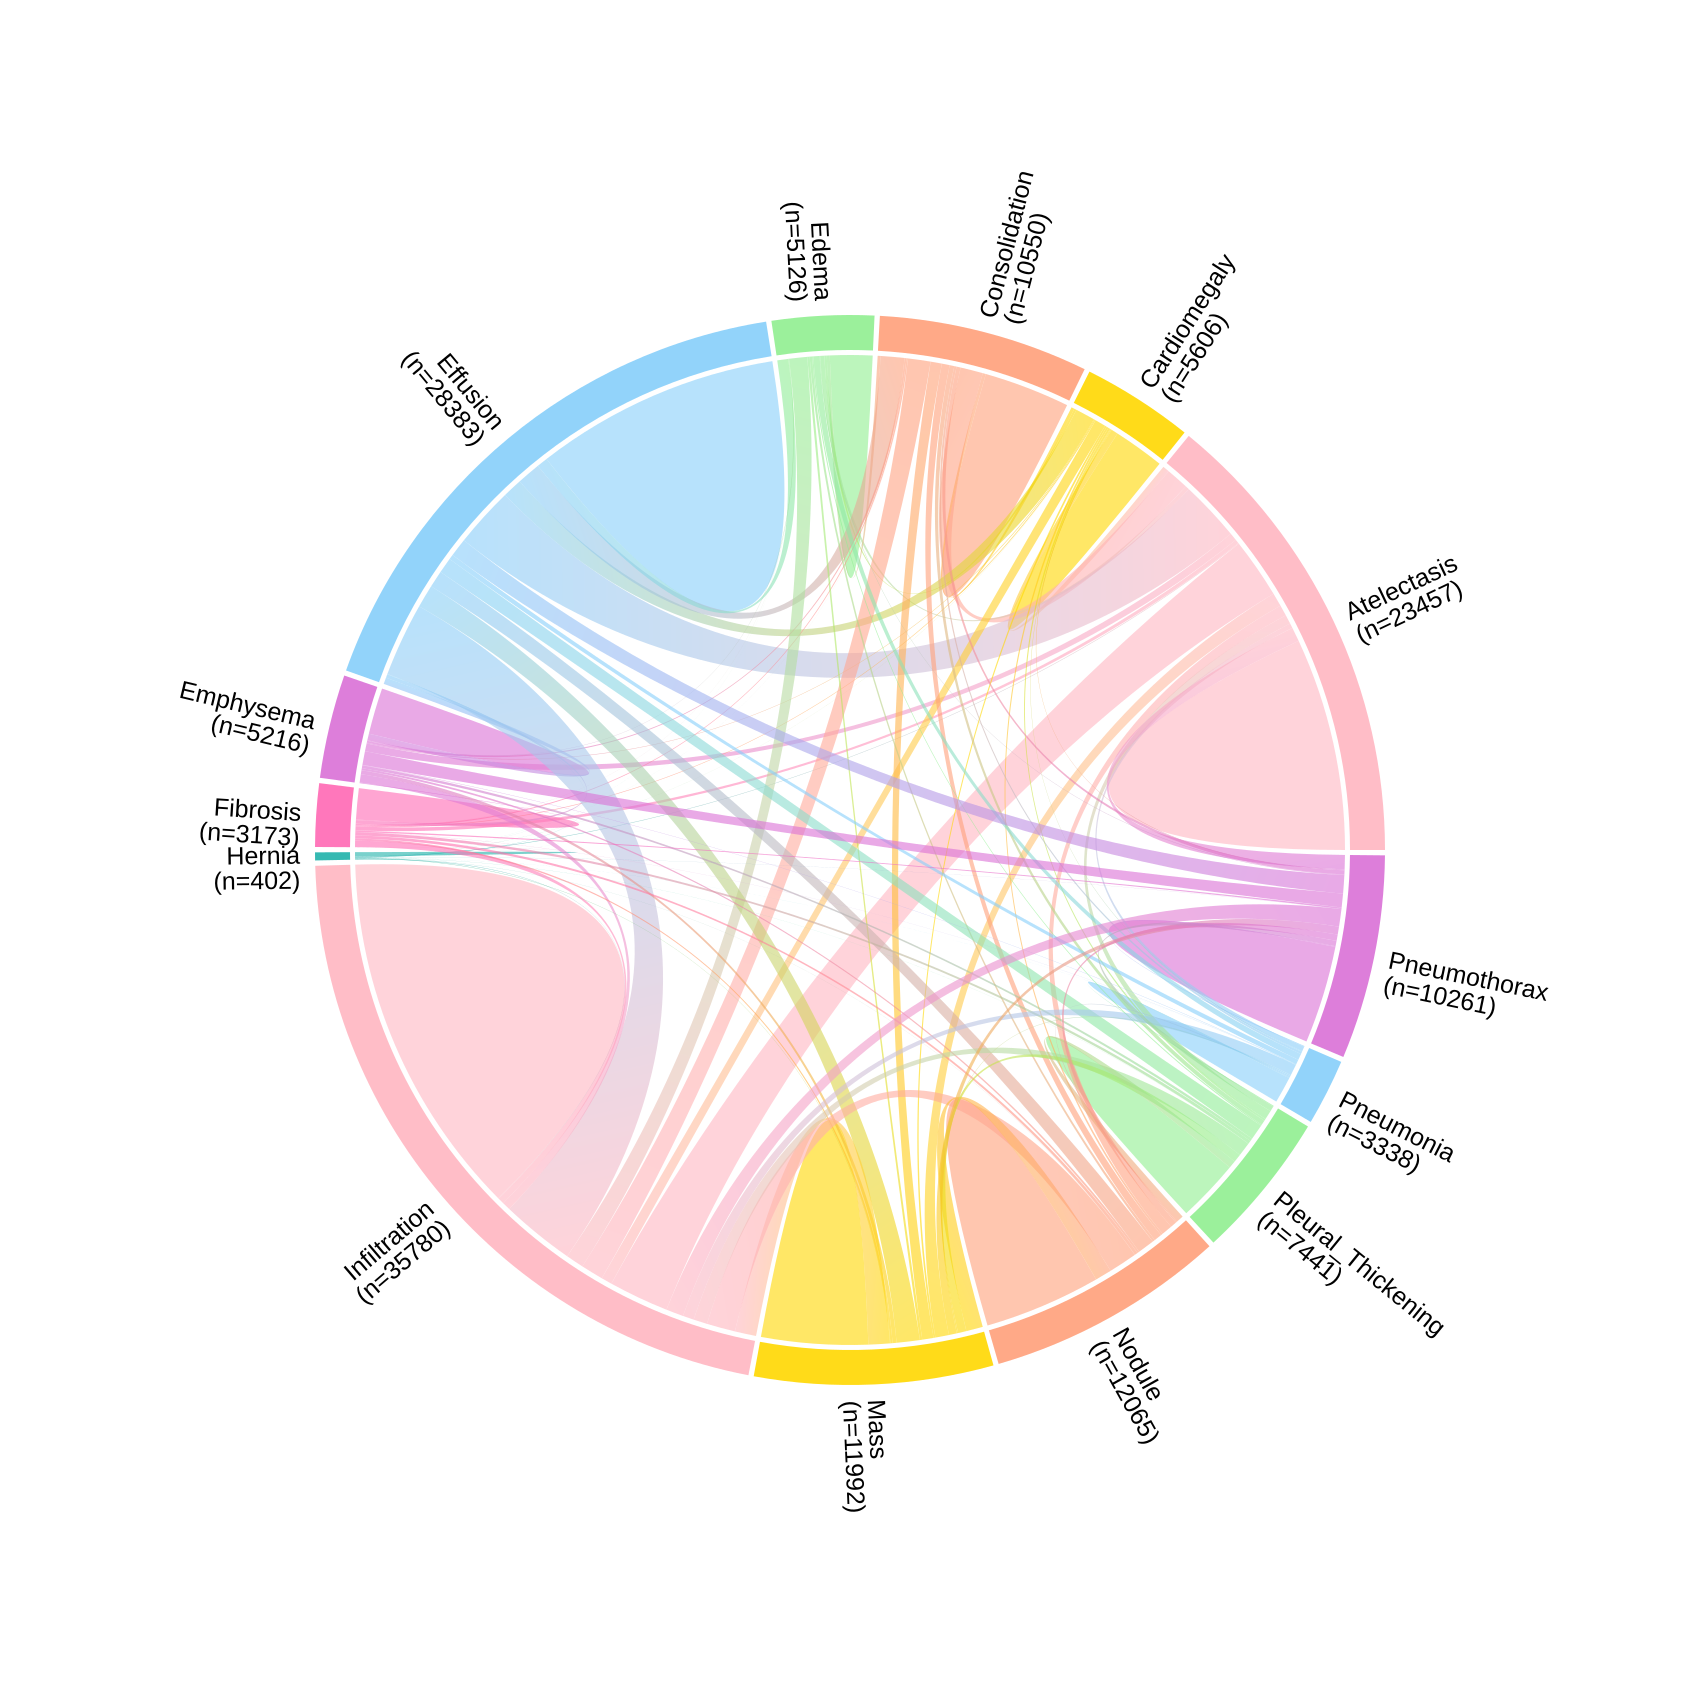

In [53]:
totals = adjacency_matrix.sum(axis=1)

labels_with_counts = [f"{name}\n(n={int(total)})" for name, total in zip(pathologies, totals)]

fig = create_ocd_chord(adjacency_matrix, labels_with_counts)
fig.show()

# Age, gender and viev position analysis

### 1. Age distribution

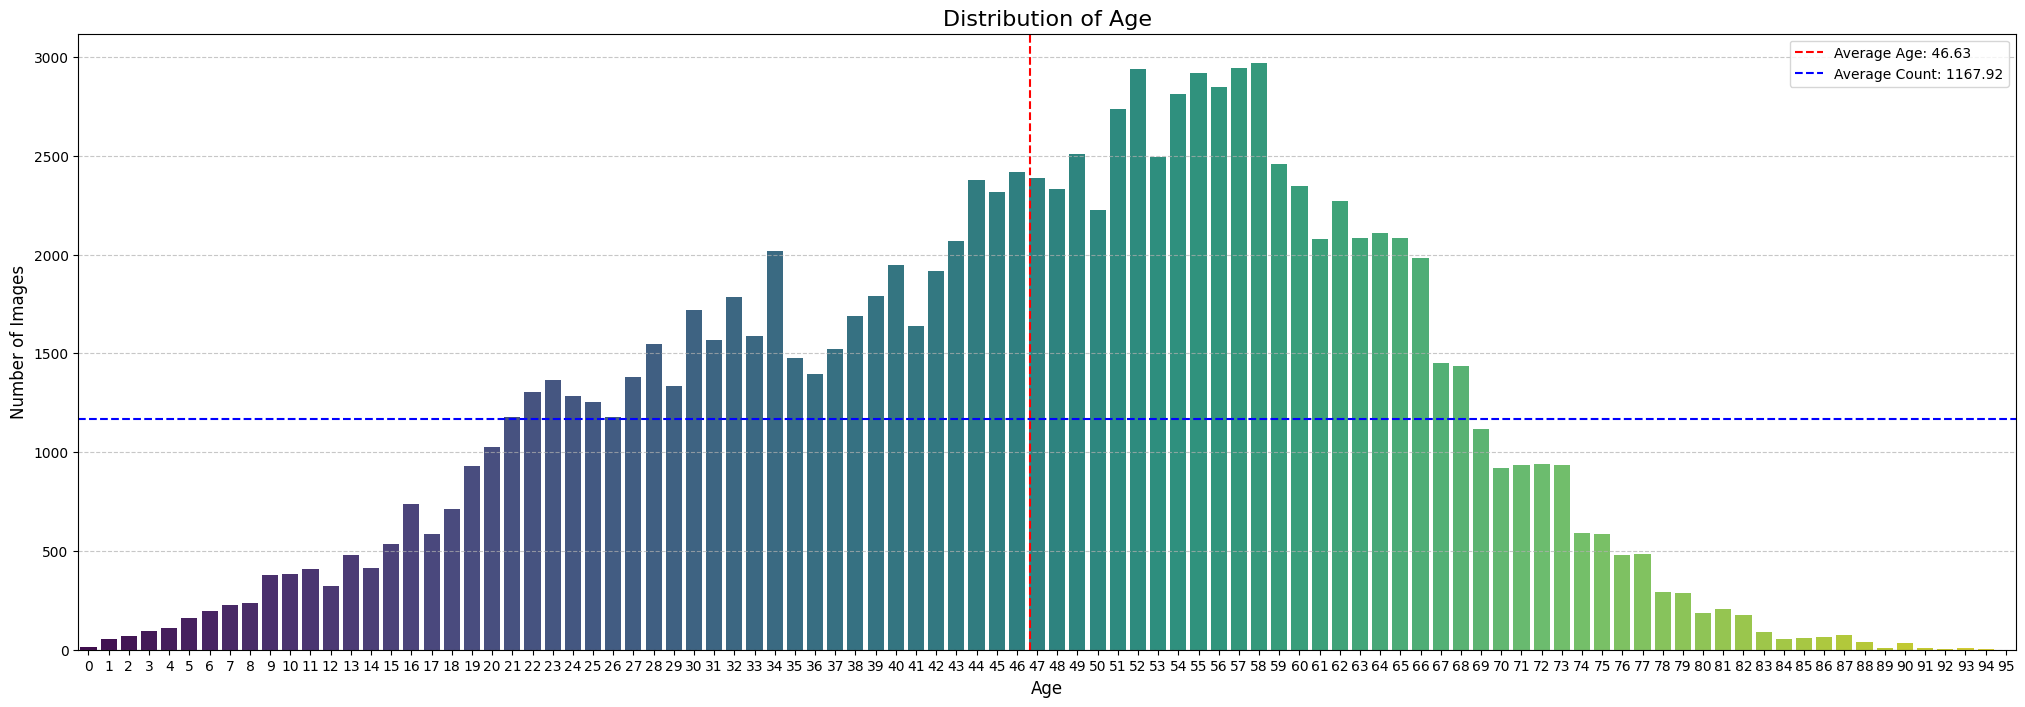

In [13]:
age_counts = metadata["patient_age"].value_counts().sort_index()
avg_age = metadata["patient_age"].mean()
avg_count = age_counts.mean()


plt.figure(figsize=(25, 8))
sns.barplot(x=age_counts.index, y=age_counts.values, palette="viridis")
plt.axvline(x=avg_age, color="red", linestyle="--", label=f"Average Age: {avg_age:.2f}")
plt.axhline(y=avg_count, color="blue", linestyle="--", label=f"Average Count: {avg_count:.2f}")
plt.title("Distribution of Age", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.legend()
plt.show()

### 2. Age - pathology correlation

In [14]:
pathology_age_dict = {}

for pathology in unique_labels:
    pathology_ages = metadata[metadata["finding_labels"].str.contains(pathology)]["patient_age"]
    pathology_age_dict[pathology] = pathology_ages


print(f"{'Pathology':<20} | {'Average Age':<12} | {'Median Age':<12} | {'Age Std Dev':<12}")
print("-" * 60)
for pathology, ages in pathology_age_dict.items():
    avg_age = ages.mean()
    median_age = ages.median()
    std_dev_age = ages.std()
    print(f"{pathology:<20} | {avg_age:<12.2f} | {median_age:<12.2f} | {std_dev_age:<12.2f}")

Pathology            | Average Age  | Median Age   | Age Std Dev 
------------------------------------------------------------
Cardiomegaly         | 47.01        | 49.00        | 17.25       
Emphysema            | 50.08        | 54.00        | 17.36       
Effusion             | 49.52        | 52.00        | 16.24       
No Finding           | 45.48        | 47.00        | 16.53       
Hernia               | 63.01        | 62.00        | 13.29       
Infiltration         | 45.96        | 48.00        | 17.03       
Mass                 | 48.48        | 51.00        | 16.04       
Nodule               | 49.25        | 51.00        | 15.34       
Atelectasis          | 50.25        | 52.00        | 15.75       
Pneumothorax         | 46.26        | 48.00        | 17.08       
Pleural_Thickening   | 50.24        | 53.00        | 16.33       
Pneumonia            | 44.41        | 46.00        | 17.65       
Fibrosis             | 52.48        | 53.00        | 15.06       
Edema          

#### Boxplot

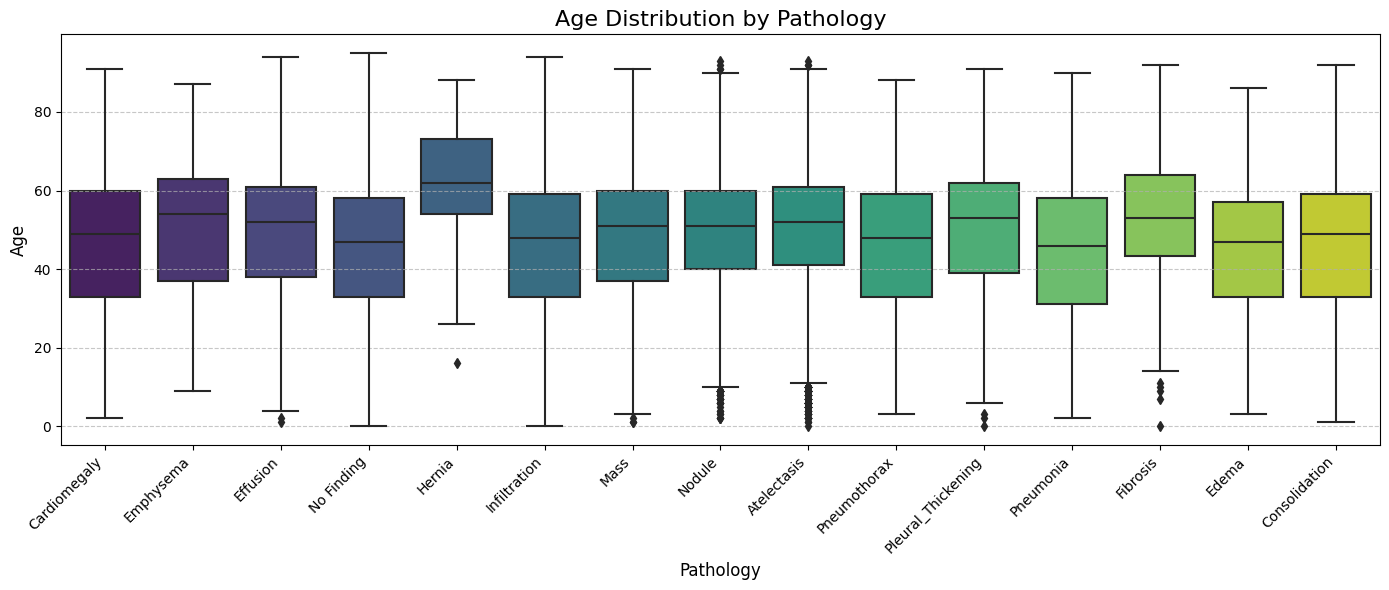

In [15]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=pd.DataFrame(
        [(pathology, age) for pathology, ages in pathology_age_dict.items() for age in ages],
        columns=["Pathology", "Age"],
    ),
    x="Pathology",
    y="Age",
    palette="viridis",
)
plt.title("Age Distribution by Pathology", fontsize=16)
plt.xlabel("Pathology", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Gender distribution

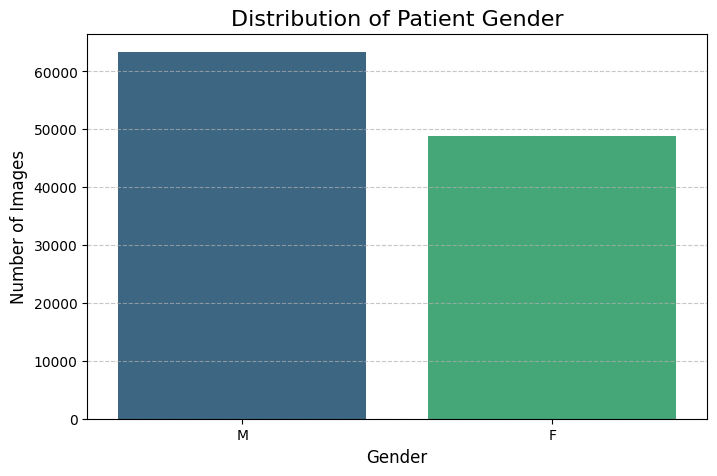

In [17]:
gender_counts = metadata["patient_sex"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="viridis")
plt.title("Distribution of Patient Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [20]:
pathology_gender_dict = {}

for pathology in unique_labels:
    gender_counts = metadata[metadata["finding_labels"].str.contains(pathology)]["patient_sex"].value_counts()
    pathology_gender_dict[pathology] = gender_counts

print(f"{'Pathology':<20} | {' Male Count':<12} |  {'Female Count':<12} | {'Male %':<10} | {'Female %':<10}")
print("-" * 80)
for pathology, gender_counts in pathology_gender_dict.items():
    male_count = gender_counts.get("M", 0)
    female_count = gender_counts.get("F", 0)
    total_count = male_count + female_count

    print(
        f"{pathology:<20} | {male_count:<12} | {female_count:<12} | {(male_count / total_count * 100) if total_count > 0 else 0:<10.2f} | {(female_count / total_count * 100) if total_count > 0 else 0:<10.2f}"
    )

Pathology            |  Male Count  |  Female Count | Male %     | Female %  
--------------------------------------------------------------------------------
Cardiomegaly         | 1307         | 1469         | 47.08      | 52.92     
Emphysema            | 1610         | 906          | 63.99      | 36.01     
Effusion             | 7435         | 5882         | 55.83      | 44.17     
No Finding           | 33922        | 26439        | 56.20      | 43.80     
Hernia               | 96           | 131          | 42.29      | 57.71     
Infiltration         | 11427        | 8467         | 57.44      | 42.56     
Mass                 | 3529         | 2253         | 61.03      | 38.97     
Nodule               | 3685         | 2646         | 58.21      | 41.79     
Atelectasis          | 6906         | 4653         | 59.75      | 40.25     
Pneumothorax         | 2717         | 2585         | 51.24      | 48.76     
Pleural_Thickening   | 2042         | 1343         | 60.32      | 39.68

In [40]:
gender_df = pd.DataFrame(pathology_gender_dict).T
gender_df = gender_df.reset_index().rename(columns={"index": "Pathology"})
gender_df

patient_sex,Pathology,F,M
0,Cardiomegaly,1469,1307
1,Emphysema,906,1610
2,Effusion,5882,7435
3,No Finding,26439,33922
4,Hernia,131,96
5,Infiltration,8467,11427
6,Mass,2253,3529
7,Nodule,2646,3685
8,Atelectasis,4653,6906
9,Pneumothorax,2585,2717


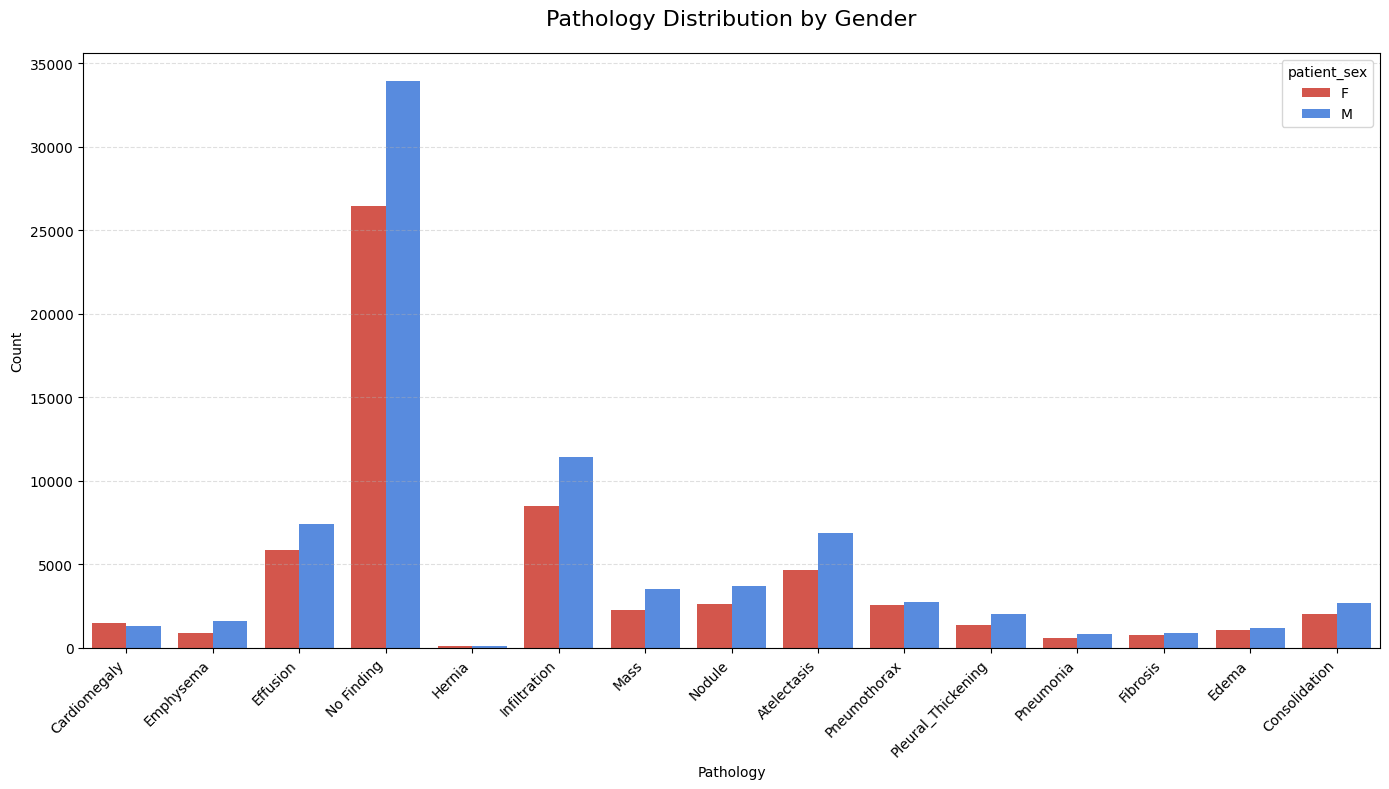

In [ ]:
gender_melted = gender_df.melt(id_vars="Pathology", var_name="patient_sex", value_name="Count")

plt.figure(figsize=(14, 8))
sns.barplot(data=gender_melted, x="Pathology", y="Count", hue="patient_sex", palette={"M": "#4285F4", "F": "#EA4335"})

plt.title("Pathology Distribution by Gender", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

### 4. View position analysis

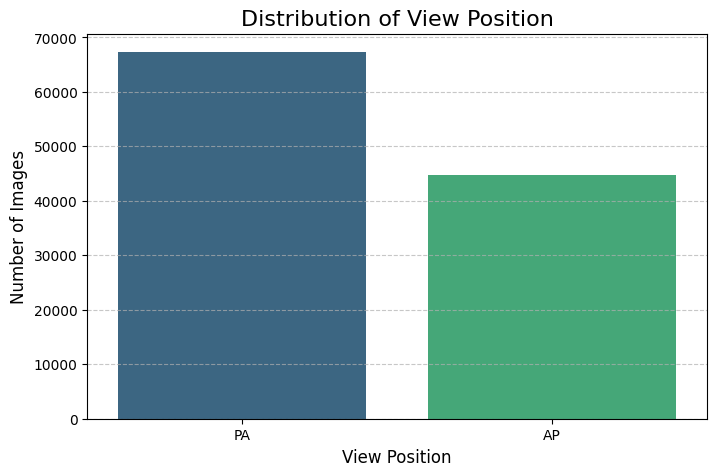

In [ ]:
vp = metadata["view_position"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=vp.index, y=vp.values, palette="viridis")
plt.title("Distribution of View Position", fontsize=16)
plt.xlabel("View Position", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
pathology_vp_dict = {}
for pathology in unique_labels:
    vp_counts = metadata[metadata["finding_labels"].str.contains(pathology)]["view_position"].value_counts()
    pathology_vp_dict[pathology] = vp_counts

print(f"{'Pathology':<20} | {'AP Count':<10} | {'PA Count':<10} | {'AP %':<10} | {'PA %':<10}")
print("-" * 70)
for pathology, vp_counts in pathology_vp_dict.items():
    ap_count = vp_counts.get("AP", 0)
    pa_count = vp_counts.get("PA", 0)
    total_count = ap_count + pa_count

    print(
        f"{pathology:<20} | {ap_count:<10} | {pa_count:<10} | {(ap_count / total_count * 100) if total_count > 0 else 0:<10.2f} | {(pa_count / total_count * 100) if total_count > 0 else 0:<10.2f}"
    )

Pathology            | AP Count   | PA Count   | AP %       | PA %      
----------------------------------------------------------------------
Cardiomegaly         | 1213       | 1563       | 43.70      | 56.30     
Emphysema            | 1017       | 1499       | 40.42      | 59.58     
Effusion             | 6728       | 6589       | 50.52      | 49.48     
No Finding           | 21059      | 39302      | 34.89      | 65.11     
Hernia               | 35         | 192        | 15.42      | 84.58     
Infiltration         | 10541      | 9353       | 52.99      | 47.01     
Mass                 | 2215       | 3567       | 38.31      | 61.69     
Nodule               | 2154       | 4177       | 34.02      | 65.98     
Atelectasis          | 5831       | 5728       | 50.45      | 49.55     
Pneumothorax         | 1895       | 3407       | 35.74      | 64.26     
Pleural_Thickening   | 967        | 2418       | 28.57      | 71.43     
Pneumonia            | 801        | 630        | 55.9

In [45]:
vp_df = pd.DataFrame(pathology_vp_dict).T
vp_df = vp_df.reset_index().rename(columns={"index": "Pathology"})
vp_df

view_position,Pathology,AP,PA
0,Cardiomegaly,1213,1563
1,Emphysema,1017,1499
2,Effusion,6728,6589
3,No Finding,21059,39302
4,Hernia,35,192
5,Infiltration,10541,9353
6,Mass,2215,3567
7,Nodule,2154,4177
8,Atelectasis,5831,5728
9,Pneumothorax,1895,3407


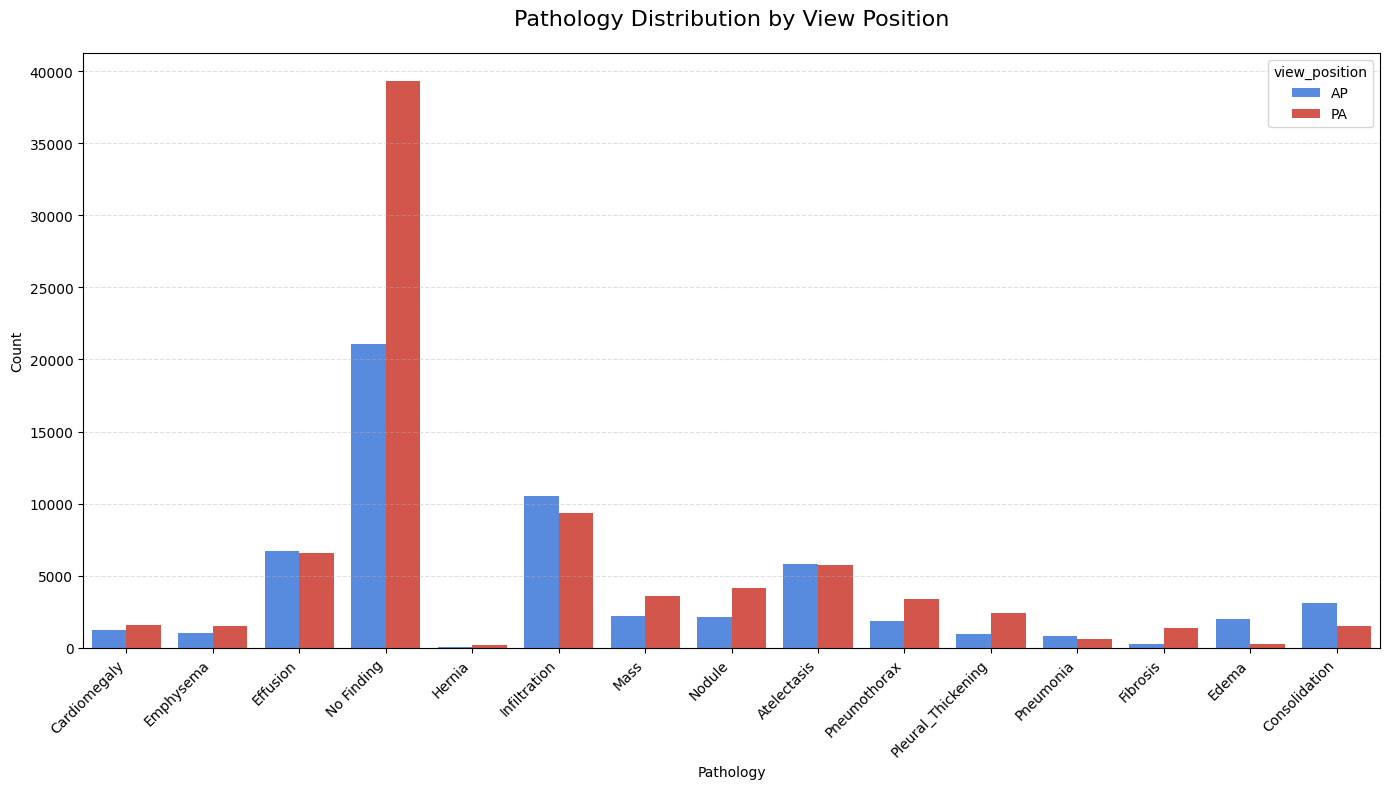

In [ ]:
vp_melted = vp_df.melt(id_vars="Pathology", var_name="view_position", value_name="Count")

plt.figure(figsize=(14, 8))
sns.barplot(data=vp_melted, x="Pathology", y="Count", hue="view_position", palette={"AP": "#4285F4", "PA": "#EA4335"})

plt.title("Pathology Distribution by View Position", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()